In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import sigpy.plot as pl
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt


## My files
import save_data_helpers
import recon_plot_helpers
from custom_recons.created_app import TotalVariationRecon_Stacked
from custom_recons.tv_app import TotalVariation_Phase_Stacked
from coils import coil_utils

In [2]:
data_bins = save_data_helpers.read_pickle('/data/lilianae/data_and_spoke_bins/patient3_mid0283_data_bins_5gates.pkl')
dcf_bins = save_data_helpers.read_pickle('/data/lilianae/subject3_mid0283_processed/dcf_512_5gates.pkl')
spoke_bins = save_data_helpers.read_pickle('/data/lilianae/data_and_spoke_bins/patient3_mid0283_spoke_bins_5gates.pkl')
# mps = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject3_mid0283/espirit_conj_all_slices_mps_full_res_ksp_512_ungated.pkl')
# mps = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject3_mid0283/espirit_conj_norm_all_slices_mps_full_res_ksp_512_ungated.pkl')
mps = np.ones((15,58,512,512), dtype=np.complex128)
# mps = save_data_helpers.read_pickle("/home/lilianae/projects/naf_clean/coils/subject3_mid0283/coil_maps_KZ_TV_conj_no_smooth_ksp_512_ungated.pkl")

In [3]:
num_gates = len(data_bins)
data_bins_with_dcf = [None] * num_gates

## Create list of data_bins with dcf applied
for gate in range(num_gates):
    data_bins_with_dcf[gate] = data_bins[gate] * dcf_bins[gate]
    print(f'Data bins w/ dcf shape = {data_bins_with_dcf[gate].shape}')
    print(f'coords shape = {spoke_bins[gate].shape}')


Data bins w/ dcf shape = (15, 58, 368, 512)
coords shape = (58, 368, 512, 3)
Data bins w/ dcf shape = (15, 58, 368, 512)
coords shape = (58, 368, 512, 3)
Data bins w/ dcf shape = (15, 58, 368, 512)
coords shape = (58, 368, 512, 3)
Data bins w/ dcf shape = (15, 58, 368, 512)
coords shape = (58, 368, 512, 3)
Data bins w/ dcf shape = (15, 58, 370, 512)
coords shape = (58, 370, 512, 3)


In [4]:
# img_shape = (58, 512, 512)
# device = 2

# with cp.cuda.Device(device):
#     ###################################################################
#     # PRE-INITIALIZATION: Independent TV reconstructions
#     ###################################################################

#     ind_recons = cp.zeros((num_gates, *img_shape), dtype=cp.complex64)

#     for i in range(1):
#         print(f"\rPre-initialization: TV recon for gate {i}/{num_gates}", end='', flush=True)
#         print()
#         tv_preinit_alg = TotalVariationRecon_Stacked(y=data_bins_with_dcf[i],
#                                             mps=np.conj(mps),
#                                             lamda=1e-3, 
#                                             coord=spoke_bins[i],
#                                             device=device,
#                                             z=None, 
#                                             max_iter=50,
#                                             max_power_iter=10,
#                                             show_pbar=True)
#         ind_recons[i, ...] = tv_preinit_alg.run()
#         del tv_preinit_alg

In [5]:
img_shape = (58, 512, 512)
device = 2

with cp.cuda.Device(device):
    ###################################################################
    # PRE-INITIALIZATION: Independent TV reconstructions
    ###################################################################

    ind_recons = cp.zeros((num_gates, *img_shape), dtype=cp.complex64)

    for i in range(1):
        print(f"\rPre-initialization: TV recon for gate {i}/{num_gates}", end='', flush=True)
        print()
        tv_preinit_alg = TotalVariation_Phase_Stacked(y=data_bins_with_dcf[i],
                                            mps=mps,
                                            lamda=0, 
                                            coord=spoke_bins[i],
                                            device=device,
                                            z=None, 
                                            max_iter=50,
                                            max_power_iter=10,
                                            show_pbar=True)
        ind_recons[i, ...] = tv_preinit_alg.run()
        del tv_preinit_alg

Pre-initialization: TV recon for gate 0/5


MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

TotalVariation_Phase_Stacked:   0%|          | 0/50 [00:00<?, ?it/s]

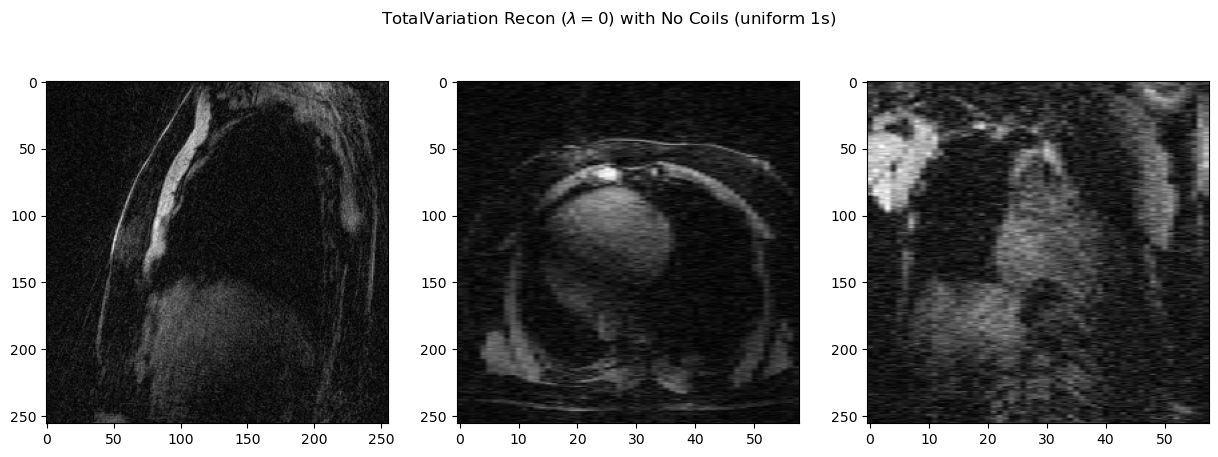

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [6]:
gate0_recon = recon_plot_helpers.crop_xy_dimension(cp.asnumpy(ind_recons[0]), oshape=(58, 256, 256))
recon_plot_helpers.plot_recons_all_axes(gate0_recon, z_idx=44, title=rf"TotalVariation Recon ($\lambda=0$) with No Coils (uniform 1s)")